In [7]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import torch
import os
from sklearn.model_selection import train_test_split
from scipy.io import loadmat
import seaborn as sns
sns.set_style("whitegrid")
from model import *
from torch.utils.data import DataLoader, Dataset

torch.set_default_dtype(torch.float64)

## Read and visualize data, no downsampling

In [19]:
data = loadmat('dataset.mat')
X = data['X']
Y = data['X_dot']
t = data['T']
XX = np.append(X,t,axis=1)
X.shape, Y.shape, t.shape

# downsampling
#X = X[:25000]
#Y = Y[:25000]
#t = t[:25000]
#XX = np.append(X,t,axis=1)
#X.shape, Y.shape, t.shape

((200000, 2), (200000, 2), (200000, 1))

Text(0, 0.5, '$x_2$')

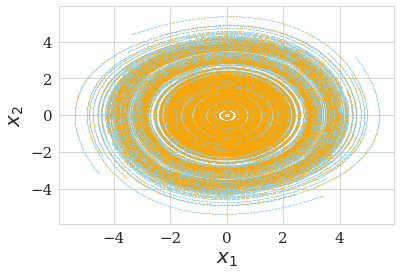

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(XX, Y, test_size=0.2)
# visualize train and test points
fontsize=15
plt.scatter(X_train[:,0], X_train[:,1], s=0.1, color='skyblue', label='training')
plt.scatter(X_test[:,0], X_test[:,1], s=0.1, color='orange', label='test')
plt.xticks(size = fontsize, fontname = 'serif')
plt.yticks(size = fontsize, fontname = 'serif')
plt.xlabel(r'$x_1$', size=20)
plt.ylabel(r'$x_2$', size=20)

## Solution Estimation

In [4]:
N = 50
sigma = 4
reg_param = 0.0001

W = np.random.randn(3,N) / sigma
b = np.random.uniform(0, 2*np.pi, size=(N,))

# compute random features matrix and coefficients
A = np.cos(X_train @ W + b) * np.sqrt(2/N)
c1 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,0])
c2 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,1])

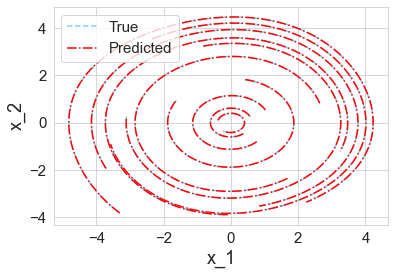

In [15]:
def g(x,t):
    x1, x2 = x
    A = np.cos(W[0] * x1 + W[1] * x2 + W[2] * t + b)
    return [np.sum(A * c1.reshape(-1) * np.sqrt(2/N)), np.sum(A * c2.reshape(-1) * np.sqrt(2/N))]

def fun(x, t, mu):
    x1, x2 = x
    return [x2, mu * (1-x1**2) * x2 - x1]


mu = 0.02

# time stamps
deltat = 0.01
t = np.arange(0.14, 5.15, deltat)
# 10 initial conditions
m_test =10
x_0 = np.random.uniform(-4,4,size=(m_test,2))

for i in range(m_test):
    
    # solve
    sol = odeint(fun, x_0[i], t, args=(mu,))
    sol_app = odeint(g, x_0[i], t)

    # transpose the solution, each row is a trajectory
    data = sol.T
    data1 = sol_app.T
    
    plt.plot(data[0], data[1], '--', c='skyblue')
    plt.plot(data1[0], data1[1], '-.', c='red')

plt.legend(['True', 'Predicted'], fontsize=15 )
plt.xticks(size=15)
plt.yticks(size=15)
plt.xlabel(r'x_1', size=18)
plt.ylabel(r'x_2', size=18)
plt.savefig('Eg3_RF_sol.pdf', bbox_inches = 'tight')

## Define random features

In [16]:
######################## Non-trajectory
n = 20 #grid points where we do the recovery

#define recovery domain boundaries
x_low = -4
x_top = 4
t_low = 0
t_top = 5.

#generate grid of x and t in the recovery domain
x1 = np.linspace(x_low, x_top, n)
x2 = np.linspace(x_low, x_top, n)
time1 = np.linspace(t_low, t_top, n)
T,X1, X2 = np.meshgrid(time1,x1, x2)

mu = 0.02

#Generate input for netowrk
new_X1 = X1.reshape(-1,1)
new_X2 = X2.reshape(-1,1)
new_X = np.append(new_X1, new_X2, axis = 1)
new_T = T.reshape(-1,1)
X_new = np.append(new_X, new_T, axis = 1)
net_input = torch.from_numpy(X_new)

#compute true RHS on grid
Z1 = new_X2
Z2 = mu * (1-new_X1**2) * new_X2 - new_X1

Z = np.append(Z1,Z2,axis=1)

In [20]:
# downsampling (required for quick verification)
X = X[:25000]
Y = Y[:25000]
t = t[:25000]
XX = np.append(X,t,axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(XX, Y, test_size=0.2)

In [21]:
# Setup Parameters
N_range = range(10,201,10)      # number of features
sigma_range = np.linspace(0.2,4,20)  # variance parameter
T = 10                          # repeat T times
reg_param = 0.00001             # fixed regularization parameter

# record errors
train_errors = np.zeros((T, len(N_range), len(sigma_range)))
test_errors = np.zeros((T, len(N_range), len(sigma_range)))
non_rel_errors = np.zeros((2, T, len(N_range), len(sigma_range)))

Lip_cons = np.zeros((2,T, len(N_range), len(sigma_range)))

for t in range(T):
    
    for i in range(len(N_range)):
        
        N = N_range[i]
        
        for j in range(len(sigma_range)):
            
            sigma = sigma_range[j]
            W = np.random.randn(3,N) / sigma
            b = np.random.uniform(0, 2*np.pi, size=(N,))
            A = np.cos(X_train @ W + b) * np.sqrt(2/N)
            c1 = np.linalg.solve(A.T@A + reg_param * np.linalg.norm(W,axis=0), A.T@Y_train[:,0])
            c2 = np.linalg.solve(A.T@A + reg_param * np.linalg.norm(W,axis=0), A.T@Y_train[:,1])
            
            # estimate Lipschitz constant
            Lip_cons[0,t,i,j] = np.sum( np.abs(c1.reshape(-1)) * np.linalg.norm(W,axis=0) )
            Lip_cons[1,t,i,j] = np.sum( np.abs(c2.reshape(-1)) * np.linalg.norm(W,axis=0) )

            # training loss
            train_errors[t,i,j] = ( np.sum((A @ c1 - Y_train[:,0])**2) + np.sum((A @ c2 - Y_train[:,1])**2) ) / A.shape[0]

            # test loss
            A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
            test_errors[t,i,j] = ( np.sum((A_test @ c1 - Y_test[:,0])**2) + np.sum((A_test @ c2 - Y_test[:,1])**2) ) / A_test.shape[0]

            # non-trajectory data relative errors
            A_non = np.cos(X_new @ W + b) * np.sqrt(2/N)
            Z_RF = A_non @ c1
            non_rel_errors[0,t,i,j] = np.mean(abs(Z1.reshape(-1) - Z_RF))/ np.abs(np.max(Z1)-np.min(Z1))
            
            Z_RF = A_non @ c2
            non_rel_errors[1,t,i,j] = np.mean(abs(Z2.reshape(-1) - Z_RF))/ np.abs(np.max(Z2)-np.min(Z2))

In [35]:
np.savez_compressed('errors.npz', train=train_errors, test=test_errors, rel=non_rel_errors, Lip=Lip_cons)

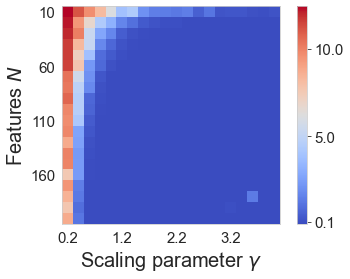

In [34]:
im = plt.imshow(np.mean(test_errors, axis=0), cmap='coolwarm')
plt.grid(visible=False)
cb = plt.colorbar(im,ticks=[0.1,5,10])
cb.ax.tick_params(labelsize=15)
plt.xticks([0,5,10,15],[0.2,1.2,2.2,3.2], size=15)
plt.yticks([0,5,10,15],[10, 60, 110, 160], size=15)
plt.xlabel(r'Scaling parameter $\gamma$', size=20)
plt.ylabel(r'Features $N$', size=20)
plt.savefig('Para_test_eg3.pdf', bbox_inches = 'tight')

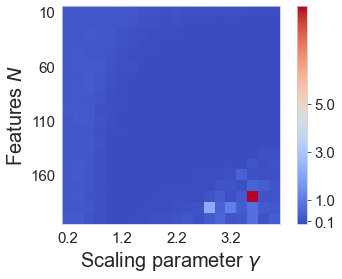

In [32]:
# first component
im = plt.imshow(np.mean(non_rel_errors[0], axis=0), cmap='coolwarm')
plt.grid(visible=False)
cb = plt.colorbar(im,ticks=[0.1,1,3,5])
cb.ax.tick_params(labelsize=15)
plt.xticks([0,5,10,15],[0.2,1.2,2.2,3.2], size=15)
plt.yticks([0,5,10,15],[10, 60, 110, 160], size=15)
plt.xlabel(r'Scaling parameter $\gamma$', size=20)
plt.ylabel(r'Features $N$', size=20)
plt.savefig('Para_rel_eg3_com1.pdf', bbox_inches = 'tight')

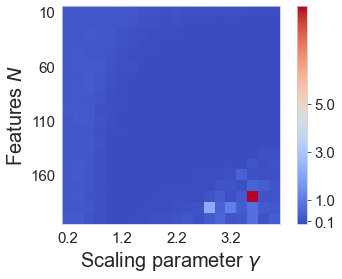

In [33]:
# first component
im = plt.imshow(np.mean(non_rel_errors[0], axis=0), cmap='coolwarm')
plt.grid(visible=False)
cb = plt.colorbar(im,ticks=[0.1,1,3,5])
cb.ax.tick_params(labelsize=15)
plt.xticks([0,5,10,15],[0.2,1.2,2.2,3.2], size=15)
plt.yticks([0,5,10,15],[10, 60, 110, 160], size=15)
plt.xlabel(r'Scaling parameter $\gamma$', size=20)
plt.ylabel(r'Features $N$', size=20)
plt.savefig('Para_rel_eg3_com2.pdf', bbox_inches = 'tight')

Scaling parameter is 1.9999999999999998
Slope is  -1.7665329646190684


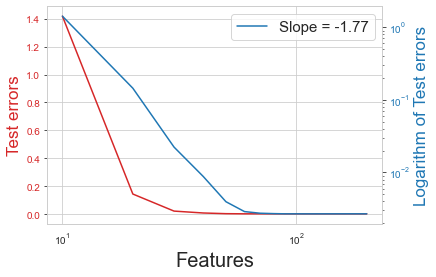

In [39]:
fig, ax1 = plt.subplots()

idx = 9
print('Scaling parameter is', sigma_range[idx])

color = 'tab:red'
ax1.set_xlabel('Features', size=20)
ax1.set_ylabel('Test errors', color=color, size=17)
ax1.plot(N_range, np.mean(test_errors,axis=0)[:,idx], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

k = np.polyfit(np.log(N_range), np.log(np.mean(test_errors,axis=0)[:,idx]), deg=1)[0]
print('Slope is ', k)

color = 'tab:blue'
ax2.set_ylabel('Logarithm of Test errors', color=color, size=17)  # we already handled the x-label with ax1
ax2.loglog(N_range, np.mean(test_errors,axis=0)[:,idx], color=color, label=f'Slope = {k:.2f}')
ax2.legend(fontsize=15)
ax2.tick_params(axis='y', labelcolor=color)

plt.grid(visible=False)
plt.savefig('Para_N_eg3.pdf', bbox_inches = 'tight')